## 시각화 기초

### Matplotlib
- Python 데이터분석에서 가장 많이 사용되는 차트 / 그래프 패키지

#### 기본 데이터 세팅

In [ ]:
# 기본적으로 필요한 패키지
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# 차트용 패키지
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 한글 출력 문제 해결
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # utf-8 등 국제어 사용시 - 표시가 깨짐 방지

In [ ]:
# 기본데이터
data = {
    "order_date": [
        "2026-09-01", "2026-09-01", "2026-09-02", "2026-09-02",
        "2026-09-03", "2026-09-03", "2026-09-04", "2026-09-04",
        "2026-09-05", "2026-09-05"
    ],
    "customer": ["홍길동", "김철수", "이영희", "홍길동", "박민수", "김철수", "최지훈", "이영희", "홍길동", "박민수"],
    "category": ["주변기기", "주변기기", "컴퓨터", "저장장치", "주변기기", "저장장치", "컴퓨터", "주변기기", "저장장치", "컴퓨터"],
    "product": ["키보드", "마우스", "노트북", "USB", "마우스", "USB", "노트북", "키보드", "SSD", "모니터"],
    "quantity": [2, 1, 1, 5, 3, 4, 1, 2, 1, 1],
    "unit_price": [30000, 15000, 1200000, 12000, 15000, 12000, 1200000, 30000, 90000, 250000]
}
df = pd.DataFrame(data)

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['total_price'] = df['quantity'] * df['unit_price']
df

#### 결측치 및 이상치 제거 필요

In [ ]:
# Pandas로 볼 수 있는 기본통계
df.describe()

In [ ]:
# 카테고리별
display(df['category'].value_counts()) 
# 상품별
display(df['product'].value_counts())

#### Maplotlib 사용법

##### 선 그래프

In [ ]:
plt.Figure(figsize=(10,5))  #figsize=(넓이,높이)
# 왼쪽이 가로 오른쪽이 세로
plt.plot([1,2,3,4],[10,20,15,30])
plt.title('선그래프')
plt.xlabel('가로축')
plt.ylabel('세로축')
plt.show()

In [ ]:
#날짜별 매출 계산
dayly_sales = df.groupby('order_date')['total_price'].sum().reset_index()

plt.Figure(figsize=(10,5))
plt.plot(
    dayly_sales['order_date'], 
    dayly_sales['total_price'],
    marker='o' ,
    markersize = 7,
    linewidth = 2.5,
    color = "#DF2323"
)
# 마커위치에 실제 데이터 표시
for x,y in zip(dayly_sales['order_date'],dayly_sales['total_price']) :
    plt.text(
        x, y,
        f"{y:,}",       # y값
        ha='center',    # 가로축 정렬 left, center, right
        va='bottom'     # 세로축 정렬 top, center, bottom
    )
plt.title('일자별 판매금액', fontsize=15, fontweight='bold')
plt.ticklabel_format(style='plain',axis='y')    # y축을 판매금액 그대로 출력

# 실제 데이터가 있는 위치의 x좌표 레이블만 표시
plt.xticks(
    dayly_sales['order_date'],
    dayly_sales['order_date'].to_string('%m-%d')
)

plt.show()

##### 막대 그래프
- 항복별(카테고리) 크기를 비교할때 사용

In [ ]:
cate_sales = df.groupby('category')['total_price'].sum().reset_index()

plt.Figure(figsize=(10,5))
# 막대그래프는 plt.bar(~~)
plt.bar(cate_sales['category'], cate_sales['total_price'])
plt.title('항목별 판매금액', fontsize=15, fontweight='bold')
plt.xlabel('카테고리', fontsize=12,fontweight='bold')
plt.ylabel('판매금액', fontsize=12,fontweight='bold')
plt.ticklabel_format(style='plain',axis='y')    # y축을 판매금액 그대로 출력
plt.show()

##### 히스토그램
- 표준편차, 분포와 관계있는 그래프
- 숫자 데이터의 분포를 확인할 때 사용

In [ ]:
plt.Figure(figsize=(10,5))

plt.hist(df['total_price'],bins=5)  #bins = 구간갯수
plt.title('구매금액 분포도',fontsize=15,fontweight='bold')
plt.ticklabel_format(style='plain',axis='x') 
plt.show()

##### 산점도
- 두 숫자 데이터간의 관계의 확인 그래프
- 데이터 분석시 가장 많이 사용됨

In [ ]:
plt.Figure(figsize=(10,5))

# 산점도
plt.scatter(x= df['quantity'],y= df['total_price'])

plt.title('구매수량, 금액간의 관계도', fontsize=15, fontweight='bold')
plt.xlabel('구매 갯수', fontsize=12,fontweight='bold')
plt.ylabel('판매 가격', fontsize=12,fontweight='bold')

plt.ticklabel_format(style='plain',axis='y')

plt.show()

##### 박스플롯
- 데이터의 이상치와 분포를 같이 확인할 때 사용

In [ ]:
plt.Figure(figsize=(10,5))

# 박스플롯
plt.boxplot(df['total_price'])

plt.title('구매금액 분포와 이상치', fontsize=15, fontweight='bold')
plt.ylabel('구매금액')
plt.ticklabel_format(style='plain',axis='y')

plt.show()

#### Seaborn 패키지
- Maplotlib를 좀 더 예쁘게 출력 지원
- Seaborn용 차트 기능도 존재

In [ ]:
sns.set_theme(style='darkgrid', font='Malgun Gothic')

plt.Figure(figsize=(10,5))  #figsize=(넓이,높이)
# 왼쪽이 가로 오른쪽이 세로
#plt.plot([1,2,3,4],[10,20,15,30])
sns.lineplot(
    x = [1,2,3,4],
    y = [10,20,15,30],
    marker='o' ,
    markersize = 7,
    linewidth = 2.5,
    color = "#1F74B1",   # RGB

)
plt.title('선그래프', fontsize=16, fontweight='bold')
plt.xlabel('가로축')
plt.ylabel('세로축')

# 선정리해줌
sns.despine()
plt.show()

##### Seaborn으로 손쉽게 차트 구현
- Seaborn은 DF를 매개변수로 활용가능
    - Matplotlib은 Pasdas DF를 바로 사용못함
- Seaborn은 데이터프레임 그대로 data속성에 전달
    - Matplotlib은 x,y 값을 시리즈로 만들어서 전달

In [ ]:
plt.Figure(figsize=(10,5))
# 막대그래프 plt.bar() -> Seaborn.barplot()로 변경
sns.barplot(data=cate_sales,x='category', y='total_price')
plt.title('항목별 판매금액', fontsize=15, fontweight='bold')
plt.xlabel('카테고리', fontsize=12,fontweight='bold')
plt.ylabel('판매금액', fontsize=12,fontweight='bold')
plt.ticklabel_format(style='plain',axis='y')    # y축을 판매금액 그대로 출력
plt.show()

##### Seaborn Heatmap
- 숫자 데이터 분포를 색상으로 표현하는 그래프

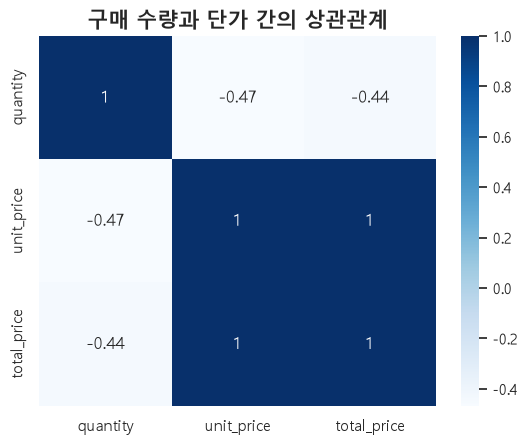

In [56]:
# 구매수량, 단가, 구매금액 간의 상관관계
corr =df[['quantity','unit_price','total_price']].corr()

plt.Figure(figsize=(10,5))
sns.heatmap(data=corr, annot=True, cmap="Blues")
plt.title('구매 수량과 단가 간의 상관관계', fontsize=15, fontweight='bold')
plt.show()